In [ ]:
%pip install -r requirements.txt

In [6]:
# # Mounting the drive
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# cells to save data commented out

In [1]:
import pandas as pd
import geopandas as gpd

## Section for 2019-2023 ACS Data

In [ ]:
# Installing / calling the necessary libraries

%pip install census #install census if you haven't already

from census import Census


In [3]:
#set up API key. This is my (Wylie) specific API key but we can all use it :)
api_key = 'd4d5470c09f30e27329890124dea292c7da295b7'
c = Census(key=api_key)

*How to figure out the ACS table columns names we want:*

1. Go to https://api.census.gov/data/2023/acs/acs5/groups.html <- this page shows all the tables available for 5 year 2023 ACS data.

2. Command-F to search for keywords that you're interested in, eg. "transportation". This sometimes requires a bit of trial & error to find what you want lol.

    Example tables:
    - Means of Transportation to Work
    - Time of Departure to Go to Work
    - Travel Time to Work

3. Once you find the table you're interested in, click into the "selected variables". This will show you all the columns within the selected table. We will typically only want the estimates (variables ending in E) and margins of error (variables ending in M), and ignore the annotations.


    **Example:**

    Table = B08302 - Time of departure to work

    Variables we want =

      - B08302_001E - Estimate, Total
      - B08302_001M - Margin of Error, Total
      - B08302_002E - Estimate, 12:00 a.m. to 4:59 a.m.
      - B08302_002M - Margin of Error, 12:00 a.m. to 4:59 a.m.
      - etc. for all the time segments

4. Create a dictionary for the variables we want (in the cell below!) and then use the api to pull them in :)

In the cell below, we need to specify the geographies we want to pull data for. We want to get data **for** all the census tracts **in** the 9 counties of the Bay Area.

Codes for states and counties can be found here: https://www2.census.gov/geo/pdfs/maps-data/data/tiger/tiger2006se/app_a03.pdf
(or ask chatgpt / gemini)

In [4]:
#Create a dictionary for the ACS table columns we want to pull in - commute times, and label the columns what we want
vars = {
    'NAME': 'NAME',                 #always want to bring in the name and geoID columns
    'GEO_ID': 'GEO_ID',
    'B01003_001E': 'total_pop',     #from a different table, getting the full tract populations
    'B01003_001M': 'total_pop_moe',
    'B08302_001E': 'total_commuters',         #this is total number of commuters aged 16+
    'B08302_001M': 'total_commuters_moe',     #moe = margin of error, we might want to use this for any stats analysis later
    'B08302_002E': '00:00_05:00',
    'B08302_002M': '00:00_05:00_moe',
    'B08302_003E': '05:00_05:30',
    'B08302_003M': '05:00_05:30_moe',
    'B08302_004E': '05:30_06:00',
    'B08302_004M': '05:30_06:00_moe',
    'B08302_005E': '06:00_06:30',
    'B08302_005M': '06:00_06:30_moe',
    'B08302_006E': '06:30_07:00',
    'B08302_006M': '06:30_07:00_moe',
    'B08302_007E': '07:00_07:30',
    'B08302_007M': '07:00_07:30_moe',
    'B08302_008E': '07:30_08:00',
    'B08302_008M': '07:30_08:00_moe',
    'B08302_009E': '08:00_08:30',
    'B08302_009M': '08:00_08:30_moe',
    'B08302_010E': '08:30_09:00',
    'B08302_010M': '08:30_09:00_moe',
    'B08302_011E': '09:00_10:00',
    'B08302_011M': '09:00_10:00_moe',
    'B08302_012E': '10:00_11:00',
    'B08302_012M': '10:00_11:00_moe',
    'B08302_013E': '11:00_12:00',
    'B08302_013M': '11:00_12:00_moe',
    'B08302_014E': '12:00_16:00',
    'B08302_014M': '12:00_16:00_moe',
    'B08302_015E': '16:00_00:00',
    'B08302_015M': '16:00_00:00_moe'
}

In [5]:
#load the raw data

departure_times_raw = pd.DataFrame(
    c.acs5.get( #api call to get the data, acs5 corresponds to the 5-year estimates
        list(vars.keys()), #use the dictionary keys to get the ACS columns we want
        {'for': 'tract', # all tracts
         'in': 'state:06 county:001,013,041,055,075,081,085,095,097'}, # California = 06, 9 Bay Area counties
        year=2023 #2019-2023
    ))

In [7]:
#Save the raw data

#departure_times_raw.to_csv("/content/drive/MyDrive/Urban_Informatics_Final_Project/Colab/Data/acs5_2023_Bay_Area_departure_times_raw.csv",index=False)


In [8]:
#load data with renamed columns

departure_times = pd.DataFrame(
    c.acs5.get( #api call to get the data, acs5 corresponds to the 5-year estimates
        list(vars.keys()), #use the dictionary keys to get the ACS columns we want
        {'for': 'tract', # all tracts
         'in': 'state:06 county:001,013,041,055,075,081,085,095,097'}, # California = 06, 9 Bay Area counties
        year=2023 #2019-2023
    )).rename(columns=vars)

In [9]:
#check the DataFrame - delete this when we combine code cells
departure_times.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1772 entries, 0 to 1771
Data columns (total 37 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   NAME                 1772 non-null   object 
 1   GEO_ID               1772 non-null   object 
 2   total_pop            1772 non-null   float64
 3   total_pop_moe        1772 non-null   float64
 4   total_commuters      1772 non-null   float64
 5   total_commuters_moe  1772 non-null   float64
 6   00:00_05:00          1772 non-null   float64
 7   00:00_05:00_moe      1772 non-null   float64
 8   05:00_05:30          1772 non-null   float64
 9   05:00_05:30_moe      1772 non-null   float64
 10  05:30_06:00          1772 non-null   float64
 11  05:30_06:00_moe      1772 non-null   float64
 12  06:00_06:30          1772 non-null   float64
 13  06:00_06:30_moe      1772 non-null   float64
 14  06:30_07:00          1772 non-null   float64
 15  06:30_07:00_moe      1772 non-null   f

In [10]:
#take a sample to see what the data looks like
departure_times.sample(3)

,NAME,GEO_ID,total_pop,total_pop_moe,total_commuters,total_commuters_moe,00:00_05:00,00:00_05:00_moe,05:00_05:30,05:00_05:30_moe,...,10:00_11:00_moe,11:00_12:00,11:00_12:00_moe,12:00_16:00,12:00_16:00_moe,16:00_00:00,16:00_00:00_moe,state,county,tract
539,Census Tract 3551.10; Contra Costa County; Cal...,1400000US06013355110,4139.0,650.0,1949.0,543.0,157.0,125.0,189.0,121.0,...,35.0,0.0,14.0,261.0,172.0,66.0,56.0,06,013,355110
659,Census Tract 1192.01; Marin County; California,1400000US06041119201,3513.0,366.0,1402.0,230.0,13.0,21.0,35.0,33.0,...,61.0,25.0,34.0,64.0,50.0,51.0,45.0,06,041,119201
464,Census Tract 3331.02; Contra Costa County; Cal...,1400000US06013333102,3947.0,602.0,1837.0,406.0,239.0,161.0,22.0,25.0,...,67.0,62.0,53.0,157.0,111.0,74.0,50.0,06,013,333102


In [11]:
departure_times_cleaned = departure_times.convert_dtypes()

departure_times_cleaned.info() #checking that we changed to the right data types - delete this line when we combine code cells

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1772 entries, 0 to 1771
Data columns (total 37 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   NAME                 1772 non-null   string
 1   GEO_ID               1772 non-null   string
 2   total_pop            1772 non-null   Int64 
 3   total_pop_moe        1772 non-null   Int64 
 4   total_commuters      1772 non-null   Int64 
 5   total_commuters_moe  1772 non-null   Int64 
 6   00:00_05:00          1772 non-null   Int64 
 7   00:00_05:00_moe      1772 non-null   Int64 
 8   05:00_05:30          1772 non-null   Int64 
 9   05:00_05:30_moe      1772 non-null   Int64 
 10  05:30_06:00          1772 non-null   Int64 
 11  05:30_06:00_moe      1772 non-null   Int64 
 12  06:00_06:30          1772 non-null   Int64 
 13  06:00_06:30_moe      1772 non-null   Int64 
 14  06:30_07:00          1772 non-null   Int64 
 15  06:30_07:00_moe      1772 non-null   Int64 
 16  07:00_

In [12]:
departure_times_cleaned.sample(3)

,NAME,GEO_ID,total_pop,total_pop_moe,total_commuters,total_commuters_moe,00:00_05:00,00:00_05:00_moe,05:00_05:30,05:00_05:30_moe,...,10:00_11:00_moe,11:00_12:00,11:00_12:00_moe,12:00_16:00,12:00_16:00_moe,16:00_00:00,16:00_00:00_moe,state,county,tract
411,Census Tract 3071.02; Contra Costa County; Cal...,1400000US06013307102,5834,773,2600,464,239,114,201,122,...,19,30,34,255,185,346,158,06,013,307102
350,Census Tract 4507.45; Alameda County; California,1400000US06001450745,6287,835,1977,474,76,75,11,18,...,35,111,82,117,152,52,45,06,001,450745
1020,Census Tract 6041.03; San Mateo County; Califo...,1400000US06081604103,4268,796,2161,434,54,58,90,95,...,58,19,36,271,99,207,138,06,081,604103


In [13]:
departure_times_cleaned["GEOID"] = departure_times_cleaned["GEO_ID"].str[-11:]
departure_times_cleaned.drop("GEO_ID", axis = 1, inplace = True)
departure_times_cleaned.head(2)


,NAME,total_pop,total_pop_moe,total_commuters,total_commuters_moe,00:00_05:00,00:00_05:00_moe,05:00_05:30,05:00_05:30_moe,05:30_06:00,...,11:00_12:00,11:00_12:00_moe,12:00_16:00,12:00_16:00_moe,16:00_00:00,16:00_00:00_moe,state,county,tract,GEOID
0,Census Tract 4001; Alameda County; California,3094,452,918,192,26,23,13,21,0,...,53,70,35,32,10,15,06,001,400100,06001400100
1,Census Tract 4002; Alameda County; California,2093,224,572,100,6,9,0,14,8,...,10,11,1,7,0,14,06,001,400200,06001400200


In [ ]:
#Now to save the data

# departure_times_cleaned.to_csv("/content/drive/MyDrive/Urban_Informatics_Final_Project/Colab/Data/acs5_2023_Bay_Area_departure_times_cleaned.csv",index=False)

In [14]:
print(departure_times_cleaned["county"].unique())

#001,013,041,055,075,081,083,095,097

<StringArray>
['001', '013', '041', '055', '075', '081', '085', '095', '097']
Length: 9, dtype: string


In [15]:
import sys
import os
from pathlib import Path

parent_path = Path.cwd().parent / "data/processed"

print("Data directory:", parent_path.resolve())

filename = "acs5_2023_Bay_Area_departure_times_cleaned.csv"
file_path = os.path.join(parent_path, filename)

departure_times_cleaned = pd.read_csv(file_path)

departure_times_cleaned.head(5)

Data directory: /Users/licin/Documents/test urban info/data/processed


UnicodeDecodeError: 'utf-8' codec can't decode byte 0xa8 in position 7: invalid start byte

## Section for 2023 LODES8 Data

### Acquiring 2023 LODES8 Data (only needs to be run once)

In [ ]:
# Here is the section for loading and cleaning LODES8 Data

%pip install pygris


In [ ]:
import pygris        # package designed to simplify accessing and loading US Census Bureau data
from pygris.data import get_lodes

lodes8_2023_od = get_lodes(state = "CA", year = 2023, lodes_type = "od") # create dataframe by pulling CA 2023 OD LODES data

In [ ]:
# save LODES raw data as a parquet file

# variable containing path string and name
lodes8_2023_od_table_path = "/content/drive/MyDrive/Urban_Informatics_Final_Project/Colab/Data/lodes8_2023_od_table_raw.parquet"

# saving LODES raw data
lodes8_2023_od.to_parquet(lodes8_2023_od_table_path)

### Cleaning Bay Area Data

In [ ]:
# load in raw data from saved parquet file on the project drive
lodes8_2023_od = pd.read_parquet("/content/drive/MyDrive/Urban_Informatics_Final_Project/Colab/Data/lodes8_2023_od_table_raw.parquet")

KeyboardInterrupt: 

In [16]:
parent_path = Path.cwd().parent / "data/raw"

print("Data directory:", parent_path.resolve())

filename = "lodes8_2023_od_table_raw.parquet"
file_path = os.path.join(parent_path, filename)

lodes8_2023_od = pd.read_parquet(file_path)

Data directory: /Users/licin/Documents/test urban info/data/raw


In [17]:
# we will need to filter the CA data by these codes to get only the data for these 9 counties

bay_area_geocodes = ['06001', # Alameda
                     '06013', # Contra Costa
                     '06041', # Marin
                     '06055', # Napa
                     '06075', # SF
                     '06081', # San Mateo
                     '06085', # Santa Clara
                     '06095', # Solano
                     '06097'  # Sonoma
                     ]

In [18]:
lodes8_2023_od.dtypes   # checking the datatypes for each column

index         int64
w_geocode    object
h_geocode    object
S000          int64
SA01          int64
SA02          int64
SA03          int64
SE01          int64
SE02          int64
SE03          int64
SI01          int64
SI02          int64
SI03          int64
dtype: object

In [19]:
# casting the two parts of the OD pair as a string just in case it wasn't already that
lodes8_2023_od['w_geocode'] = lodes8_2023_od['w_geocode'].astype(str)
lodes8_2023_od['h_geocode'] = lodes8_2023_od['h_geocode'].astype(str)
lodes8_2023_od.dtypes

index         int64
w_geocode    object
h_geocode    object
S000          int64
SA01          int64
SA02          int64
SA03          int64
SE01          int64
SE02          int64
SE03          int64
SI01          int64
SI02          int64
SI03          int64
dtype: object

In [20]:
# creating two new columns in the dataframe to slice out the state and county part of the work and home geocodes for future filtering
lodes8_2023_od['work_county'] = lodes8_2023_od['w_geocode'].str[:5]

lodes8_2023_od['home_county'] = lodes8_2023_od['h_geocode'].str[:5]

In [21]:
# creating a new dataframe that will only include OD pairs that start AND/OR end in the bay area

bay_area_lodes = lodes8_2023_od[(lodes8_2023_od['work_county'].isin(bay_area_geocodes)) | (lodes8_2023_od['home_county'].isin(bay_area_geocodes))].copy()

In [22]:
# check for duplicates
print(bay_area_lodes.duplicated().sum())
# no duplicates, great!

0


In [23]:
# comparing original CA-wide dataframe to Bay Area dataframe

print(lodes8_2023_od.count())
bay_area_lodes.count()

# dataframe has reduced from approx 16 million rows to 4 million rows

index          16241068
w_geocode      16241068
h_geocode      16241068
S000           16241068
SA01           16241068
SA02           16241068
SA03           16241068
SE01           16241068
SE02           16241068
SE03           16241068
SI01           16241068
SI02           16241068
SI03           16241068
work_county    16241068
home_county    16241068
dtype: int64


index          4083866
w_geocode      4083866
h_geocode      4083866
S000           4083866
SA01           4083866
SA02           4083866
SA03           4083866
SE01           4083866
SE02           4083866
SE03           4083866
SI01           4083866
SI02           4083866
SI03           4083866
work_county    4083866
home_county    4083866
dtype: int64

In [24]:
# creating two new columns in the dataframe to slice out the tract part of the work and home geocodes for future filtering
bay_area_lodes['work_tract'] = bay_area_lodes['w_geocode'].str[:11]

bay_area_lodes['home_tract'] = bay_area_lodes['h_geocode'].str[:11]

In [25]:
# save new dataframe as a parquet file that can be referenced going forward

# variable containing             path string                                                 and name
# bay_area_lodes_path = "/content/drive/MyDrive/Urban_Informatics_Final_Project/Colab/Data/bay_area_lodes_od_table.parquet"

# # saving and naming the bay area dataframe
# bay_area_lodes.to_parquet(bay_area_lodes_path)

## Processing Lodes Data for Plots
Group by home tract (resident population), work tract (daytime population), and within tract (to avoid double-counting those who stay in the same tract for work)



In [26]:
parent_path = Path.cwd().parent / "data/processed"

print("Data directory:", parent_path.resolve())

filename = "bay_area_lodes_od_table.parquet"
file_path = os.path.join(parent_path, filename)

bay_area_lodes = pd.read_parquet(file_path)

Data directory: /Users/licin/Documents/test urban info/data/processed


In [27]:
#Determine if home and work tracts are the same
bay_area_lodes["within_tract"] = bay_area_lodes["work_tract"] == bay_area_lodes["home_tract"]

bay_area_lodes.sample(5)

,index,w_geocode,h_geocode,S000,SA01,SA02,SA03,SE01,SE02,SE03,SI01,SI02,SI03,work_county,home_county,work_tract,home_tract,within_tract
12572131,12572131,060750155004000,060750206011002,1,0,1,0,0,0,1,0,0,1,06075,06075,06075015500,06075020601,False
15448317,15448317,060990002051011,060014502001011,1,0,1,0,0,1,0,0,0,1,06099,06001,06099000205,06001450200,False
12500355,12500355,060750118001005,060750227021008,2,1,1,0,0,0,2,0,0,2,06075,06075,06075011800,06075022702,False
12720079,12720079,060750226002004,060855015011010,1,0,1,0,0,0,1,0,0,1,06075,06085,06075022600,06085501501,False
15564991,15564991,060990026023004,060014043001024,1,0,1,0,0,0,1,0,0,1,06099,06001,06099002602,06001404300,False


In [28]:
#Group by home and work tracts
tract_pop = bay_area_lodes.groupby('work_tract')['S000'].sum().to_frame().rename_axis("GEOID")
tract_pop = tract_pop.rename(columns = {"S000": "work_pop"}).rename_axis("GEOID")

tract_pop["home_pop"] = bay_area_lodes.groupby("home_tract")["S000"].sum()

#Find number of within tract movements
#Determine if home and work tracts are the same
bay_area_lodes["within_tract"] = bay_area_lodes["work_tract"] == bay_area_lodes["home_tract"]

#group and sum
tract_pop["within_tract"] = bay_area_lodes.groupby('work_tract')['within_tract'].sum()
tract_pop.head()



,work_pop,home_pop,within_tract
GEOID,,,
06001400100,281,1426.0,21
06001400200,1100,963.0,14
06001400300,2149,2591.0,73
06001400400,803,1952.0,24
06001400500,448,1803.0,51


In [30]:
# save file
# tract_pop_path = "/content/drive/MyDrive/Urban_Informatics_Final_Project/Colab/Data/tract_pop.parquet"
# tract_pop.to_parquet(tract_pop_path)

## Section for EPC Data

### Clean MTC EPC data

In [31]:
import geopandas as gpd

In [33]:
# Here is the section for loading and cleaning EPC Data

parent_path = Path.cwd().parent / "data/raw"

print("Data directory:", parent_path.resolve())

filename = "EPC_2020_acs2018.geojson"
file_path = os.path.join(parent_path, filename)

epc = gpd.read_file(file_path)


#drop unnecessary columns
cols_to_drop = ['state_fip','county_fip', 'tract','tot_pop_ci','tot_pop_ov', 'pop_over75', 'pop_poc', 'pop_spfam', 'pop_lep',
                'pop_below2', 'pop_disabi', 'pop_hus_re','over75_1_2', 'poc_1_2', 'spfam_1_2', 'lep_1_2','below2_1_2',
                'disab_1_2', 'hus_re_1_2', 'zvhh_1_2', 'pct_over75', 'pct_poc', 'pct_spfam', 'pct_lep', 'pct_below2',
                'pct_disab', 'pct_hus_re',]
epc.drop(columns = cols_to_drop, inplace = True)

Data directory: /Users/licin/Documents/test urban info/data/raw


In [34]:
epc.columns

Index(['objectid', 'geoid', 'tot_pop', 'tot_pop_po', 'tot_hh', 'tot_fam',
       'pop_zvhhs', 'pct_zvhhs', 'epc_2035', 'epc_2040', 'epc_2050',
       'c2040_2050', 'epc_class', 'geometry'],
      dtype='object')

In [35]:
#rename
epc.rename(columns = {'tot_pop_po': 'total_pop_income', 'tot_hh': 'total_households', 'tot_fam': 'total_families',
       'pop_zvhhs': 'pop_zero_veh', 'pct_zvhhs': 'pct_zero_veh',}, inplace = True)

In [36]:
epc.head(2)

,objectid,geoid,tot_pop,total_pop_income,total_households,total_families,pop_zero_veh,pct_zero_veh,epc_2035,epc_2040,epc_2050,c2040_2050,epc_class,geometry
0,1601,06001401000,6024,6016,2439,1159,645,0.264453,1,1,1,0,High,"POLYGON ((-122.27871 37.82715, -122.27792 37.8..."
1,1604,06001401300,3855,3563,1804,457,601,0.333149,1,1,1,0,Higher,"POLYGON ((-122.27339 37.81272, -122.27138 37.8..."


In [37]:
#check for duplicates and NaN
print(epc.isna().sum().sum())
print(epc.duplicated().sum().sum())

0
0


EPSG:4326


<Axes: >

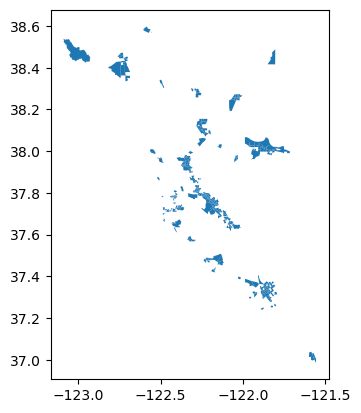

In [38]:
print(epc.crs)
epc.plot()

### Clean Bay Area census tract geometries

In [39]:
#combine with regular map
epc.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [41]:
#read California census tracts
#data from: https://www.census.gov/cgi-bin/geo/shapefiles/index.php, year 2022

parent_path = Path.cwd().parent / "data/raw"

print("Data directory:", parent_path.resolve())

filename = "tl_2022_06_tract/tl_2022_06_tract.shp"
file_path = os.path.join(parent_path, filename)

california = gpd.read_file(file_path)

Data directory: /Users/licin/Documents/test urban info/data/raw


In [42]:
california.to_crs(4326, inplace = True)
california.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [43]:
# Bay area county codes:
# 001 ALAMEDA
# 013 CONTRA COSTA
# 041 MARIN
# 055 NAPA
# 075 SAN FRANCISCO
# 081 SAN MATEO
# 085 SANTA CLARA
# 095 SOLANO
# 097 SONOMA
#filter:
county_codes = ['001', '013', '041', '055', '075', '081', '085', '095', '097']
#california["COUNTYFP"].dtype
#print(sorted(california["COUNTYFP"].unique()))


bay_counties = california[california["COUNTYFP"].isin(county_codes)]
print(sorted(bay_counties["COUNTYFP"].unique()))
bay_counties.head()
len(bay_counties)

['001', '013', '041', '055', '075', '081', '085', '095', '097']


1772

In [44]:
# check for na values
display(bay_counties)
print(bay_counties.isna().sum().sum())

,STATEFP,COUNTYFP,TRACTCE,GEOID,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
88,06,013,324002,06013324002,3240.02,Census Tract 3240.02,G5020,S,2027097,0,+37.9515743,-122.0605372,"POLYGON ((-122.07313 37.94793, -122.07276 37.9..."
89,06,013,320004,06013320004,3200.04,Census Tract 3200.04,G5020,S,5911930,20167,+37.9992449,-122.0795275,"POLYGON ((-122.10187 38.00463, -122.10186 38.0..."
90,06,013,336201,06013336201,3362.01,Census Tract 3362.01,G5020,S,1240588,0,+37.9604171,-122.0474661,"POLYGON ((-122.05429 37.95366, -122.05399 37.9..."
91,06,013,338203,06013338203,3382.03,Census Tract 3382.03,G5020,S,1577045,0,+37.9256927,-122.0541352,"POLYGON ((-122.06394 37.91739, -122.06393 37.9..."
92,06,013,338204,06013338204,3382.04,Census Tract 3382.04,G5020,S,2649159,15822,+37.9190883,-122.0467663,"POLYGON ((-122.05837 37.91039, -122.05836 37.9..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9117,06,001,444200,06001444200,4442,Census Tract 4442,G5020,S,2069720,0,+37.5425433,-122.0457280,"POLYGON ((-122.05514 37.54948, -122.05503 37.5..."
9122,06,001,444400,06001444400,4444,Census Tract 4444,G5020,S,1027755,0,+37.5362315,-122.0353380,"POLYGON ((-122.04465 37.53331, -122.04457 37.5..."
9124,06,001,444500,06001444500,4445,Census Tract 4445,G5020,S,1959283,0,+37.5342653,-122.0273658,"POLYGON ((-122.03998 37.52944, -122.03971 37.5..."
9125,06,001,450200,06001450200,4502,Census Tract 4502,G5020,S,1612601,0,+37.7224277,-121.9154123,"POLYGON ((-121.92582 37.72685, -121.9247 37.72..."


0


In [45]:
#saving the reprojected & cleaned bay counties to a parquet file

# bay_counties.to_parquet("/content/drive/MyDrive/Urban Informatics Final Project/Colab/Data/bay_counties.parquet")
# bay_counties.to_parquet("/content/drive/MyDrive/Urban_Informatics_Final_Project/Colab/Data/processed/bay_counties_cleaned.parquet")